In [1]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt

from datetime import datetime
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample

In [2]:
train = pd.read_csv("train.csv")

<Axes: >

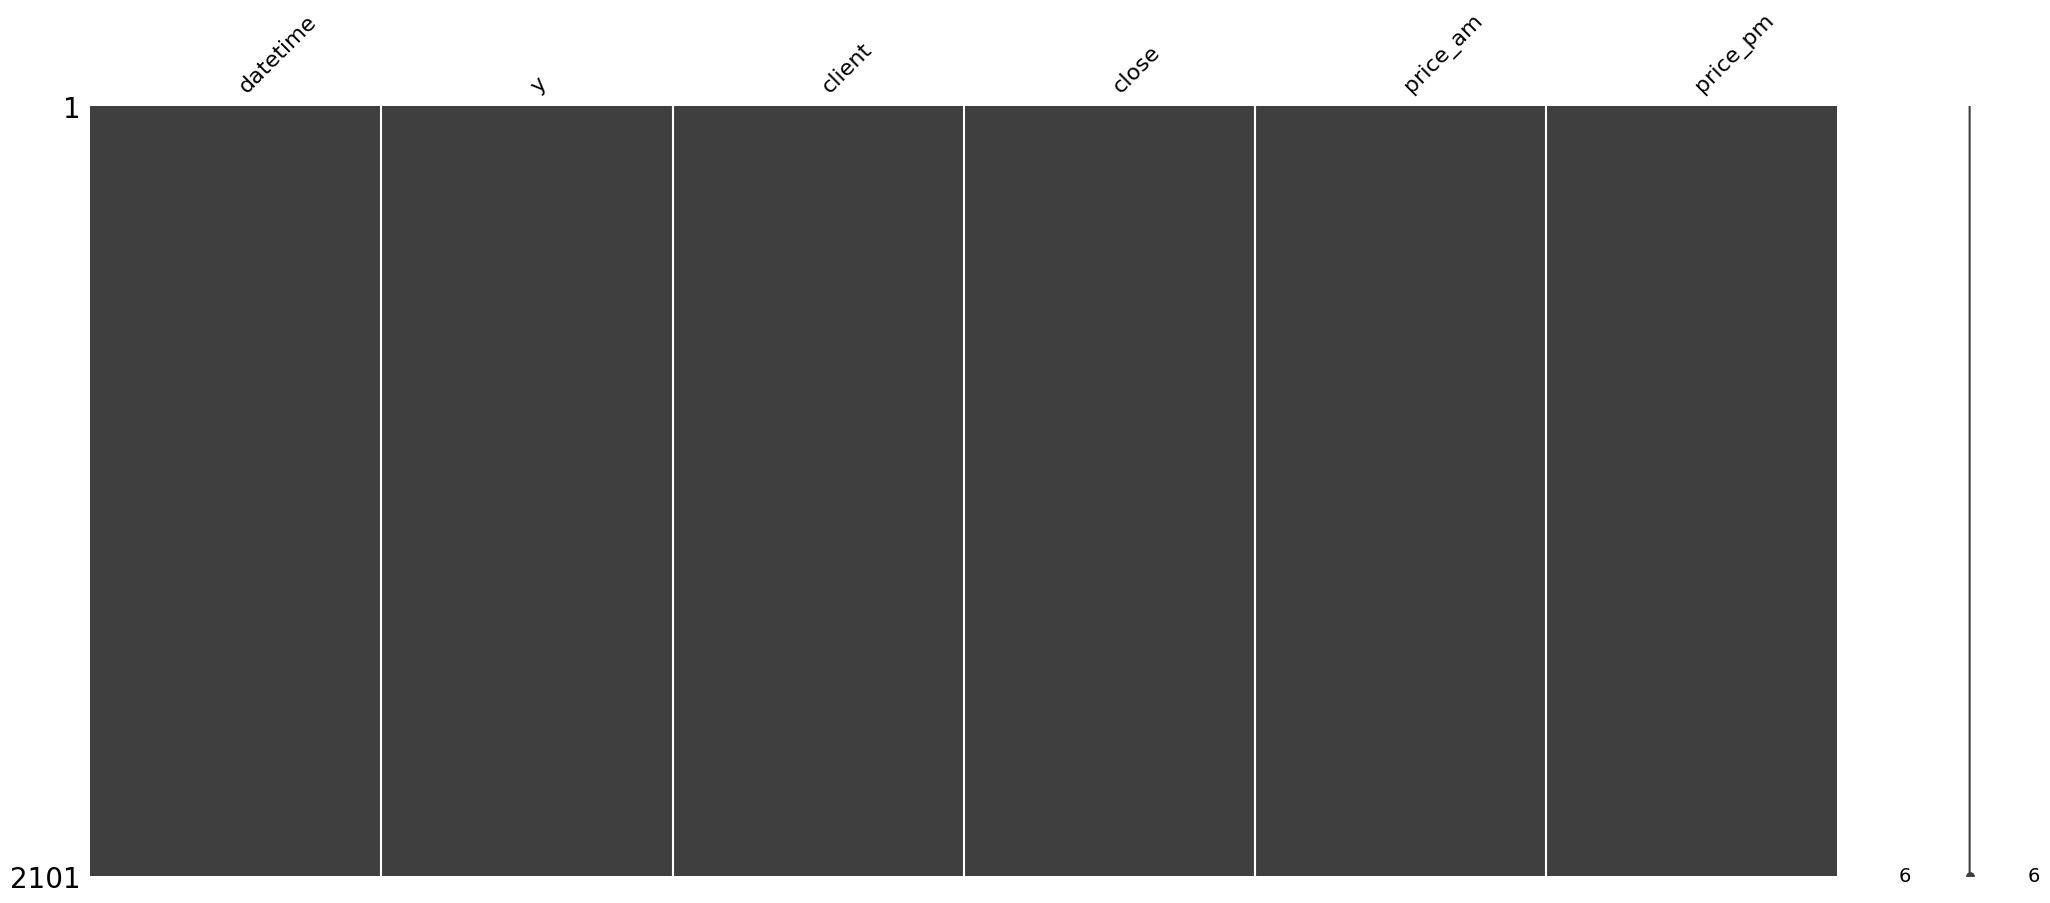

In [3]:
msno.matrix(train)

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2101 entries, 0 to 2100
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   datetime  2101 non-null   object
 1   y         2101 non-null   int64 
 2   client    2101 non-null   int64 
 3   close     2101 non-null   int64 
 4   price_am  2101 non-null   int64 
 5   price_pm  2101 non-null   int64 
dtypes: int64(5), object(1)
memory usage: 98.6+ KB


In [5]:
train.head()

,datetime,y,client,close,price_am,price_pm
0,2010-07-01,17,0,0,-1,-1
1,2010-07-02,18,0,0,-1,-1
2,2010-07-03,20,0,0,-1,-1
3,2010-07-04,20,0,0,-1,-1
4,2010-07-05,14,0,0,-1,-1


In [6]:
# datetime列をdatetime64型に変換
train["datetime"] = pd.to_datetime(train["datetime"])

# 日付の範囲を決定
min_date = train["datetime"].min()
max_date = train["datetime"].max()

# 日付を0から1の範囲にスケーリング
train["normalized_datetime"] = (train["datetime"] - min_date) / (max_date - min_date)

train.head()

,datetime,y,client,close,price_am,price_pm,normalized_datetime
0,2010-07-01,17,0,0,-1,-1,0.000000
1,2010-07-02,18,0,0,-1,-1,0.000476
2,2010-07-03,20,0,0,-1,-1,0.000952
3,2010-07-04,20,0,0,-1,-1,0.001429
4,2010-07-05,14,0,0,-1,-1,0.001905


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2101 entries, 0 to 2100
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   datetime             2101 non-null   datetime64[ns]
 1   y                    2101 non-null   int64         
 2   client               2101 non-null   int64         
 3   close                2101 non-null   int64         
 4   price_am             2101 non-null   int64         
 5   price_pm             2101 non-null   int64         
 6   normalized_datetime  2101 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(5)
memory usage: 115.0 KB


In [8]:
#price_amとprice_pmの-1は欠損のためどうにかする
#まず休日フラグが立ってるところはいらないから消す
#pre_date = train[train["close"] != 1]

#休日フラグはあとで戻す
#pre_date = train[train["close"] != 1]
#close_data = train[train["close"] == 1]

#いらないdatetimeを落とす
pre_date = train.drop(columns=["datetime"])

#休日フラグがオンなら無条件で0にする
pre_date.loc[pre_date["close"] == 1, ["price_am", "price_pm"]] = 0

In [9]:
pre_date.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2101 entries, 0 to 2100
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   y                    2101 non-null   int64  
 1   client               2101 non-null   int64  
 2   close                2101 non-null   int64  
 3   price_am             2101 non-null   int64  
 4   price_pm             2101 non-null   int64  
 5   normalized_datetime  2101 non-null   float64
dtypes: float64(1), int64(5)
memory usage: 98.6 KB


(array([184., 972.,   0., 587.,   0., 250.,  46.,   0.,  33.,  29.]),
 array([-1. , -0.4,  0.2,  0.8,  1.4,  2. ,  2.6,  3.2,  3.8,  4.4,  5. ]),
 <BarContainer object of 10 artists>)

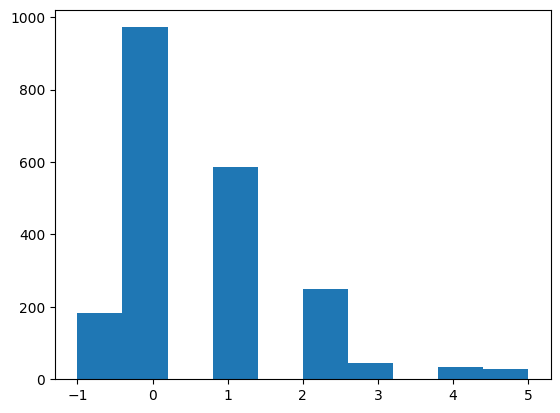

In [10]:
plt.hist(pre_date["price_am"])

(array([ 185., 1218.,    0.,  496.,    0.,  125.,   34.,    0.,   30.,
          13.]),
 array([-1. , -0.4,  0.2,  0.8,  1.4,  2. ,  2.6,  3.2,  3.8,  4.4,  5. ]),
 <BarContainer object of 10 artists>)

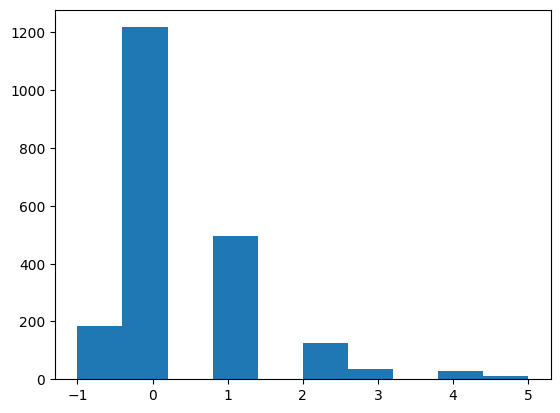

In [11]:
plt.hist(pre_date["price_pm"])

In [12]:
#一旦closeが1の部分を退避
close_data = pre_date.query("close == 1")
pre_date = pre_date.query("close == 0")

In [13]:
#amとpmに分割
pre_data_am = pre_date.drop(columns=["price_pm"])
pre_data_pm = pre_date.drop(columns=["price_am"])

In [14]:
#欠損を退避
deficiency_data_am  = pre_data_am.query("price_am == -1")
deficiency_data_pm  = pre_data_pm.query("price_pm == -1")
pre_date_am2 = pre_data_am.query("price_am != -1")
pre_date_pm2 = pre_data_pm.query("price_pm != -1")

In [15]:
# price_amとprice_pmの値をすべて1増やす
pre_date_am2.loc[:, ["price_am"]] += 1
pre_date_pm2.loc[:, ["price_pm"]] += 1

In [16]:
#マージしてソートして同じインデックスは統合
pre_date = pd.concat([close_data, deficiency_data_am, deficiency_data_pm , pre_date_am2 , pre_date_pm2])

pre_date = pre_date.sort_index()

pre_date = pre_date.groupby(pre_date.index).first()

pre_date.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2101 entries, 0 to 2100
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   y                    2101 non-null   int64  
 1   client               2101 non-null   int64  
 2   close                2101 non-null   int64  
 3   price_am             2101 non-null   float64
 4   price_pm             2101 non-null   float64
 5   normalized_datetime  2101 non-null   float64
dtypes: float64(3), int64(3)
memory usage: 114.9 KB


(array([184.,  27., 945.,   0., 587., 250.,   0.,  46.,  33.,  29.]),
 array([-1. , -0.3,  0.4,  1.1,  1.8,  2.5,  3.2,  3.9,  4.6,  5.3,  6. ]),
 <BarContainer object of 10 artists>)

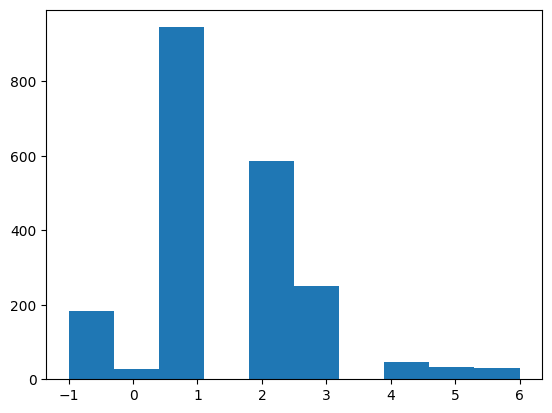

In [17]:
plt.hist(pre_date["price_am"])

(array([ 185.,   27., 1191.,    0.,  496.,  125.,    0.,   34.,   30.,
          13.]),
 array([-1. , -0.3,  0.4,  1.1,  1.8,  2.5,  3.2,  3.9,  4.6,  5.3,  6. ]),
 <BarContainer object of 10 artists>)

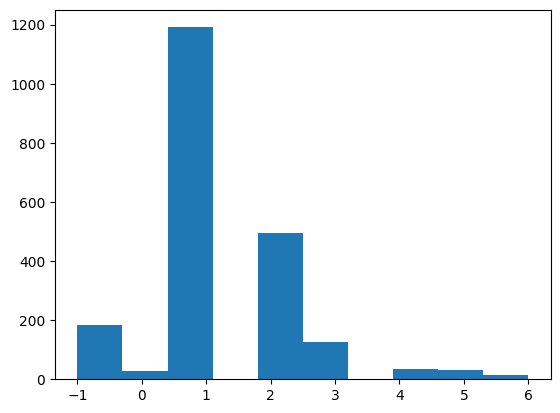

In [18]:
plt.hist(pre_date["price_pm"])

In [19]:
#price_am,pmの欠損とそれ以外でtrain,testに分割
train_am = pre_date.query("price_am != -1")
train_am = train_am.drop(columns=["price_pm"])
test_am = pre_date.query("price_am == -1")
test_am = test_am.drop(columns=["price_am", "price_pm"])

train_pm = pre_date.query("price_pm != -1")
train_pm =train_pm.drop(columns=["price_am"])
test_pm = pre_date.query("price_pm == -1")
test_pm = test_pm.drop(columns=["price_am", "price_pm"])

In [20]:
#priceをそれぞれに分割
train_am_Zero = train_am.query("price_am == 0")
train_am_One = train_am.query("price_am == 1")
train_am_Two = train_am.query("price_am == 2")
train_am_Three = train_am.query("price_am == 3")
train_am_Four = train_am.query("price_am == 4")
train_am_Five = train_am.query("price_am == 5")
train_am_Six = train_am.query("price_am == 6")

train_pm_Zero = train_pm.query("price_pm == 0")
train_pm_One = train_pm.query("price_pm == 1")
train_pm_Two = train_pm.query("price_pm == 2")
train_pm_Three = train_pm.query("price_pm == 3")
train_pm_Four = train_pm.query("price_pm == 4")
train_pm_Five = train_pm.query("price_pm == 5")
train_pm_Six = train_pm.query("price_pm == 6")

In [21]:
#1に対してアンダーサンプリング
downsampled_train_am_One = resample(train_am_One, replace=False, n_samples=700, random_state=42)

downsampled_train_pm_One = resample(train_pm_One, replace=False, n_samples=700, random_state=42)

In [22]:
#1以外に対してオーバーサンプリング
upsampled_train_am_Zero = resample(train_am_Zero, replace=True, n_samples=700, random_state=42)
upsampled_train_am_Two = resample(train_am_Two, replace=True, n_samples=700, random_state=42)
upsampled_train_am_Three = resample(train_am_Three, replace=True, n_samples=700, random_state=42)
upsampled_train_am_Four = resample(train_am_Four, replace=True, n_samples=700, random_state=42)
upsampled_train_am_Five = resample(train_am_Five, replace=True, n_samples=700, random_state=42)
upsampled_train_am_Six = resample(train_am_Six, replace=True, n_samples=700, random_state=42)

upsampled_train_pm_Zero = resample(train_pm_Zero, replace=True, n_samples=700, random_state=42)
upsampled_train_pm_Two = resample(train_pm_Two, replace=True, n_samples=700, random_state=42)
upsampled_train_pm_Three = resample(train_pm_Three, replace=True, n_samples=700, random_state=42)
upsampled_train_pm_Four = resample(train_pm_Four, replace=True, n_samples=700, random_state=42)
upsampled_train_pm_Five = resample(train_pm_Five, replace=True, n_samples=700, random_state=42)
upsampled_train_pm_Six = resample(train_pm_Six, replace=True, n_samples=700, random_state=42)

In [23]:
#マージ
balanced_train_am = pd.concat([downsampled_train_am_One, upsampled_train_am_Zero, upsampled_train_am_Two, upsampled_train_am_Three, upsampled_train_am_Four, upsampled_train_am_Five, upsampled_train_am_Six])

balanced_train_pm = pd.concat([downsampled_train_pm_One, upsampled_train_pm_Zero, upsampled_train_pm_Two, upsampled_train_pm_Three, upsampled_train_pm_Four, upsampled_train_pm_Five, upsampled_train_pm_Six])

(array([700., 700.,   0., 700.,   0., 700., 700.,   0., 700., 700.]),
 array([0. , 0.6, 1.2, 1.8, 2.4, 3. , 3.6, 4.2, 4.8, 5.4, 6. ]),
 <BarContainer object of 10 artists>)

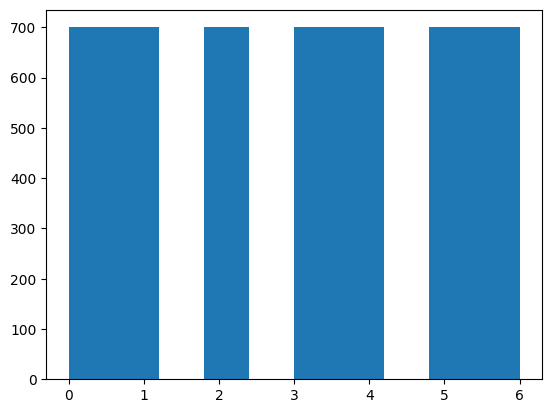

In [24]:
plt.hist(balanced_train_am["price_am"])

(array([700., 700.,   0., 700.,   0., 700., 700.,   0., 700., 700.]),
 array([0. , 0.6, 1.2, 1.8, 2.4, 3. , 3.6, 4.2, 4.8, 5.4, 6. ]),
 <BarContainer object of 10 artists>)

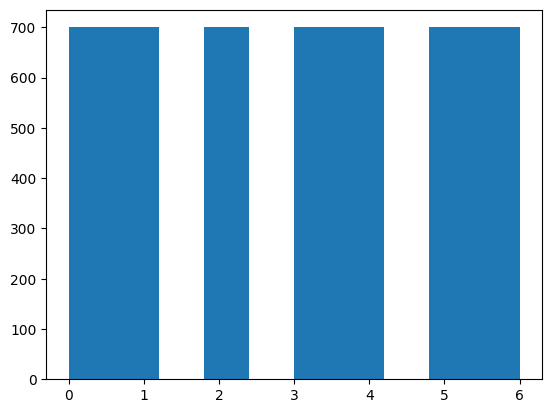

In [25]:
plt.hist(balanced_train_pm["price_pm"])

In [26]:
#Xとyに分割
X_am = balanced_train_am.drop(columns=["price_am"])
y_am = balanced_train_am["price_am"]

X_pm = balanced_train_pm.drop(columns=["price_pm"])
y_pm = balanced_train_pm["price_pm"]

In [27]:
#最適化及びモデル作成
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

model = RandomForestClassifier()

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_am = grid_search.fit(X_am, y_am)
grid_search_pm = grid_search.fit(X_pm, y_pm)

best_params_am = grid_search_am.best_params_
print("Best Parameters am:", best_params_am)
best_params_pm = grid_search_pm.best_params_
print("Best Parameters pm :", best_params_pm)

best_model_am = grid_search_am.best_estimator_
best_model_pm = grid_search_pm.best_estimator_

Best Parameters am: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best Parameters pm : {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [28]:
#評価
cv_scores_am = cross_val_score(grid_search_am.best_estimator_, X_am, y_am, cv=5, scoring='accuracy')
cv_scores_pm = cross_val_score(grid_search_pm.best_estimator_, X_pm, y_pm, cv=5, scoring='accuracy')

In [29]:
#評価の表示
print("Cross Validation Scores am:", cv_scores_am)
print("Cross Validation Scores pm:", cv_scores_pm)

Cross Validation Scores am: [0.91836735 0.92346939 0.91428571 0.92040816 0.90306122]
Cross Validation Scores pm: [0.92959184 0.93163265 0.94183673 0.93469388 0.93673469]


In [30]:
#評価平均値の表示
print("Mean Score am:", cv_scores_am.mean())
print("Mean Score pm:", cv_scores_pm.mean())

Mean Score am: 0.9159183673469388
Mean Score pm: 0.9348979591836736


In [31]:
#testの予測
y_pred_am = best_model_am.predict(test_am)

y_pred_pm = best_model_pm.predict(test_pm)

In [32]:
#price_を戻す
test_am["price_am"] = y_pred_am

test_pm["price_pm"] = y_pred_pm

In [33]:
#マージしてソートして同じインデックスは統合
pre_data2 = pd.concat([train_am, test_am, train_pm, test_pm])

pre_data2 = pre_data2.sort_index()

pre_data2 = pre_data2.groupby(pre_data2.index).first()

In [34]:
#priceをそれぞれに分割
pre_am_Zero = pre_data2.query("price_am == 0")
pre_am_One = pre_data2.query("price_am == 1")
pre_am_Two = pre_data2.query("price_am == 2")
pre_am_Three = pre_data2.query("price_am == 3")
pre_am_Four = pre_data2.query("price_am == 4")
pre_am_Five = pre_data2.query("price_am == 5")
pre_am_Six = pre_data2.query("price_am == 6")

pre_pm_Zero = pre_data2.query("price_pm == 0")
pre_pm_One = pre_data2.query("price_pm == 1")
pre_pm_Two = pre_data2.query("price_pm == 2")
pre_pm_Three = pre_data2.query("price_pm == 3")
pre_pm_Four = pre_data2.query("price_pm == 4")
pre_pm_Five = pre_data2.query("price_pm == 5")
pre_pm_Six = pre_data2.query("price_pm == 6")

In [35]:
#1に対してアンダーサンプリング
downsampled_pre_am_One = resample(pre_am_One, replace=False, n_samples=700, random_state=42)

downsampled_pre_pm_One = resample(pre_pm_One, replace=False, n_samples=700, random_state=42)

In [36]:
#1以外に対してオーバーサンプリング
upsampled_pre_am_Zero = resample(pre_am_Zero, replace=True, n_samples=700, random_state=42)
upsampled_pre_am_Two = resample(pre_am_Two, replace=True, n_samples=700, random_state=42)
upsampled_pre_am_Three = resample(pre_am_Three, replace=True, n_samples=700, random_state=42)
upsampled_pre_am_Four = resample(pre_am_Four, replace=True, n_samples=700, random_state=42)
upsampled_pre_am_Five = resample(pre_am_Five, replace=True, n_samples=700, random_state=42)
upsampled_pre_am_Six = resample(pre_am_Six, replace=True, n_samples=700, random_state=42)

upsampled_pre_pm_Zero = resample(pre_pm_Zero, replace=True, n_samples=700, random_state=42)
upsampled_pre_pm_Two = resample(pre_pm_Two, replace=True, n_samples=700, random_state=42)
upsampled_pre_pm_Three = resample(pre_pm_Three, replace=True, n_samples=700, random_state=42)
upsampled_pre_pm_Four = resample(pre_pm_Four, replace=True, n_samples=700, random_state=42)
upsampled_pre_pm_Five = resample(pre_pm_Five, replace=True, n_samples=700, random_state=42)
upsampled_pre_pm_Six = resample(pre_pm_Six, replace=True, n_samples=700, random_state=42)

In [37]:
#マージ
balanced_pre_am = pd.concat([downsampled_pre_am_One, upsampled_pre_am_Zero, upsampled_pre_am_Two, upsampled_pre_am_Three, upsampled_pre_am_Four, upsampled_pre_am_Five, upsampled_pre_am_Six])

balanced_pre_pm = pd.concat([downsampled_pre_pm_One, upsampled_pre_pm_Zero, upsampled_pre_pm_Two, upsampled_pre_pm_Three, upsampled_pre_pm_Four, upsampled_pre_pm_Five, upsampled_pre_pm_Six])

balanced_pre_data = pd.concat([balanced_pre_am, balanced_pre_pm])

(array([1400., 1268.,    0., 1364.,    0., 1508., 1137.,    0., 1542.,
        1581.]),
 array([0. , 0.6, 1.2, 1.8, 2.4, 3. , 3.6, 4.2, 4.8, 5.4, 6. ]),
 <BarContainer object of 10 artists>)

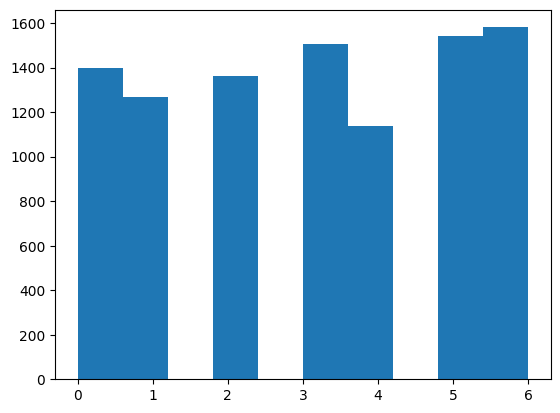

In [38]:
plt.hist(balanced_pre_data["price_am"])

(array([1400., 1726.,    0., 1513.,    0., 1519., 1290.,    0., 1345.,
        1007.]),
 array([0. , 0.6, 1.2, 1.8, 2.4, 3. , 3.6, 4.2, 4.8, 5.4, 6. ]),
 <BarContainer object of 10 artists>)

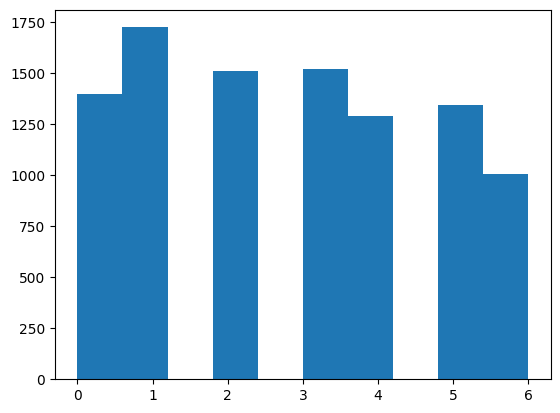

In [39]:
plt.hist(balanced_pre_data["price_pm"])

In [40]:
#確認のためにcsvへ書き出し
balanced_pre_data.to_csv("preprocess.csv", index=False)